# Lazada App Reviews - Sentimental Analysis 
### Data Source:
This notebook uses sentimental analysis on Lazada's app reviews (Google store) from Kaggle:
https://www.kaggle.com/datasets/bwandowando/lazada-app-reviews-from-google-store/data

### Objectives:
- Find out what are the customers' sentiment towards Lazada's app.

#### Data Description:
- Unnamed : Index
- review_text : Customer review
- review_rating : Customer rating ranging from 1-5
- author_id : Customer id
- author_name : Customer name
- author_app_version : App version that customer uses
- review_datetime_utc : Date and Time when customer posted their review
- review_likes : The amount of likes a review has 

## Exploratory Data Analysis (EDA)

In [2]:
# If running on a fresh environment, uncomment the pip installs below.

# !pip install pandas numpy matplotlib seaborn scikit-learn nltk emoji wordcloud langdetect
# !pip install transformers torch --upgrade
# !pip install sentencepiece # required by some multilingual Transformer models
# !pip install --upgrade imbalanced-learn

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\alsto\\anaconda3\\Lib\\site-packages\\~-mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



  Using cached emoji-2.15.0-py3-none-any.whl (608 kB)
  Using cached wordcloud-1.9.6-cp39-cp39-win_amd64.whl (306 kB)
  Using cached langdetect-1.0.9-py3-none-any.whl
  Using cached numpy-1.22.4-cp39-cp39-win_amd64.whl (14.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: Invalid requirement: '#'


In [24]:
# !pip install wordcloud
# !pip install emoji

  Using cached emoji-2.15.0-py3-none-any.whl (608 kB)


In [25]:
import sklearn

import os, re, string, random
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import emoji
from wordcloud import WordCloud

import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import nltk

# Resampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
import joblib # saving models
from sklearn.neighbors import NearestNeighbors

# Machine Learning Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore")

# Ensure NLTK assets
try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
try:
    _ = nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")
try:
    _ = nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")
    
nltk.download('punkt_tab')

sns.set_theme()
plt.rcParams["figure.dpi"] = 120

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alsto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
# loading dataset
df = pd.read_csv("LAZADA_REVIEWS.csv")

In [8]:
df.head()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
0,0,This app is a big step in right direction - gr...,5,109329*********902682,A Google user,1.0,2013-06-09T08:34:37.000Z,2
1,1,This is what I have been looking for. Now I ca...,5,109886*********190000,A Google user,1.0,2013-06-09T09:29:25.000Z,0
2,2,Its a great way of shopping online. But please...,1,114358*********899063,A Google user,1.0,2013-06-09T10:19:39.000Z,0
3,3,Thanks lazada for this app!!,5,108006*********600292,A Google user,1.0,2013-06-10T02:24:14.000Z,0
4,4,Good app ;),5,110676*********237626,A Google user,1.0,2013-06-10T02:35:53.000Z,0


In [9]:
df.shape

(775323, 8)

In [10]:
df.columns

Index(['Unnamed: 0', 'review_text', 'review_rating', 'author_id',
       'author_name', 'author_app_version', 'review_datetime_utc',
       'review_likes'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775323 entries, 0 to 775322
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           775323 non-null  int64 
 1   review_text          775209 non-null  object
 2   review_rating        775323 non-null  int64 
 3   author_id            775195 non-null  object
 4   author_name          775322 non-null  object
 5   author_app_version   600912 non-null  object
 6   review_datetime_utc  775323 non-null  object
 7   review_likes         775323 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 47.3+ MB


### **Follow up actions:**
- Split up the dataset into training and testing dataset so there isn't a data leakage.
- Are there authors who has too many comments over the others such that it can cause biasness in the app review?
- review_text needs to convert to string dtype
- review_rating will split into sentiment categories, 'positive', 'negative', 'neutral'


In [12]:
df[df['review_text'].duplicated()]

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
67,67,Good,5,117004*********121943,A Google user,1.0.1,2013-06-18T19:18:18.000Z,0
103,103,Great app,5,103579*********094848,A Google user,1.0.2,2013-07-28T13:10:44.000Z,0
115,115,Nice,4,103463*********364007,A Google user,1.0.2,2013-08-19T19:52:10.000Z,0
123,123,Good,5,101472*********807948,A Google user,1.0.2,2013-09-04T14:37:42.000Z,0
132,132,good,4,104615*********588290,A Google user,2.0.1,2013-09-15T02:34:07.000Z,0
...,...,...,...,...,...,...,...,...
775309,775309,very nice,5,102022*********273581,A Google user,7.37.0,2023-11-13T14:19:40.000Z,0
775312,775312,good,5,112571*********852590,A Google user,7.37.0,2023-11-13T14:23:41.000Z,0
775318,775318,nice,5,105611*********908291,A Google user,NaN,2023-11-13T14:35:46.000Z,0
775319,775319,Nice,5,108460*********801893,A Google user,7.37.0,2023-11-13T14:39:25.000Z,0


In [13]:
df.isna().sum()

Unnamed: 0                  0
review_text               114
review_rating               0
author_id                 128
author_name                 1
author_app_version     174411
review_datetime_utc         0
review_likes                0
dtype: int64

There are **duplicated** values in the review_text but it will be kept because the duplicated values are still needed for sentiment analysis and will not affect biasness.

There are also **missing** values in the dataset. Since we will only be looking at review_text and review_rating, we will drop all the null values in review_text since there are only afew of them.

In [14]:
df['author_id'].value_counts().sort_values(ascending=False)

106224*********970971    2
108251*********386038    2
115385*********904547    2
104626*********394665    2
101496*********456412    2
                        ..
114756*********724527    1
107455*********192107    1
107886*********152196    1
109467*********187285    1
104025*********727802    1
Name: author_id, Length: 775103, dtype: int64

The most a customer commented was **2 comments** so we do not have to worry about a single customer making too many reviews which causes bias opinions towards the app.

In [15]:
# rating will be our dependent variable so we will need to classify them under positive, negative or neutral
    
def addSentiment(df):
    def rating_to_sentiment(r):
        if r >= 4: 
            return 'positive'
        elif r <= 2: 
            return 'negative'
        else: 
            return 'neutral'
    
    df['sentiment'] = df['review_rating'].apply(rating_to_sentiment)
    return df

addSentiment(df)
df.head()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes,sentiment
0,0,This app is a big step in right direction - gr...,5,109329*********902682,A Google user,1.0,2013-06-09T08:34:37.000Z,2,positive
1,1,This is what I have been looking for. Now I ca...,5,109886*********190000,A Google user,1.0,2013-06-09T09:29:25.000Z,0,positive
2,2,Its a great way of shopping online. But please...,1,114358*********899063,A Google user,1.0,2013-06-09T10:19:39.000Z,0,negative
3,3,Thanks lazada for this app!!,5,108006*********600292,A Google user,1.0,2013-06-10T02:24:14.000Z,0,positive
4,4,Good app ;),5,110676*********237626,A Google user,1.0,2013-06-10T02:35:53.000Z,0,positive


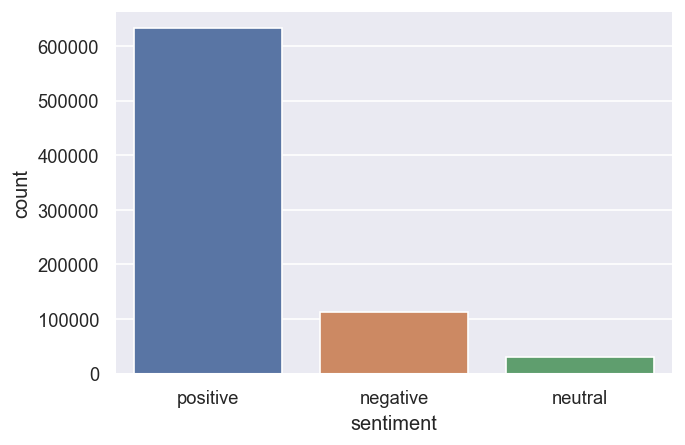

In [16]:
sns.countplot(x='sentiment', data=df)
plt.show()

##### Graph summary
There is a huge imbalance in the classification of sentiments. 'Positive' is overwhelmingly higher than the rest and neutral is very scarce. Hence, to prevent imbalanced data, resampling will be needed.

In [17]:
# changing data type to string
def change_type(df):
    df['review_text'] = df['review_text'].astype('string')
    return df

change_type(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775323 entries, 0 to 775322
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           775323 non-null  int64 
 1   review_text          775209 non-null  string
 2   review_rating        775323 non-null  int64 
 3   author_id            775195 non-null  object
 4   author_name          775322 non-null  object
 5   author_app_version   600912 non-null  object
 6   review_datetime_utc  775323 non-null  object
 7   review_likes         775323 non-null  int64 
 8   sentiment            775323 non-null  object
dtypes: int64(3), object(5), string(1)
memory usage: 53.2+ MB


In [18]:
# drop null values so we can split them up
def drop_null(df):
    df.dropna(subset=['review_text'], inplace=True)
    return df

drop_null(df)

# creating text_len to split up text into words and counting them
df['text_len'] = df['review_text'].apply(lambda x: len(x.split()))
    
print(df['text_len'].describe())
    
    

count    775209.000000
mean          7.319914
std          12.596445
min           1.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         379.000000
Name: text_len, dtype: float64


In [19]:
df.isna().sum()

Unnamed: 0                  0
review_text                 0
review_rating               0
author_id                 120
author_name                 1
author_app_version     174374
review_datetime_utc         0
review_likes                0
sentiment                   0
text_len                    0
dtype: int64

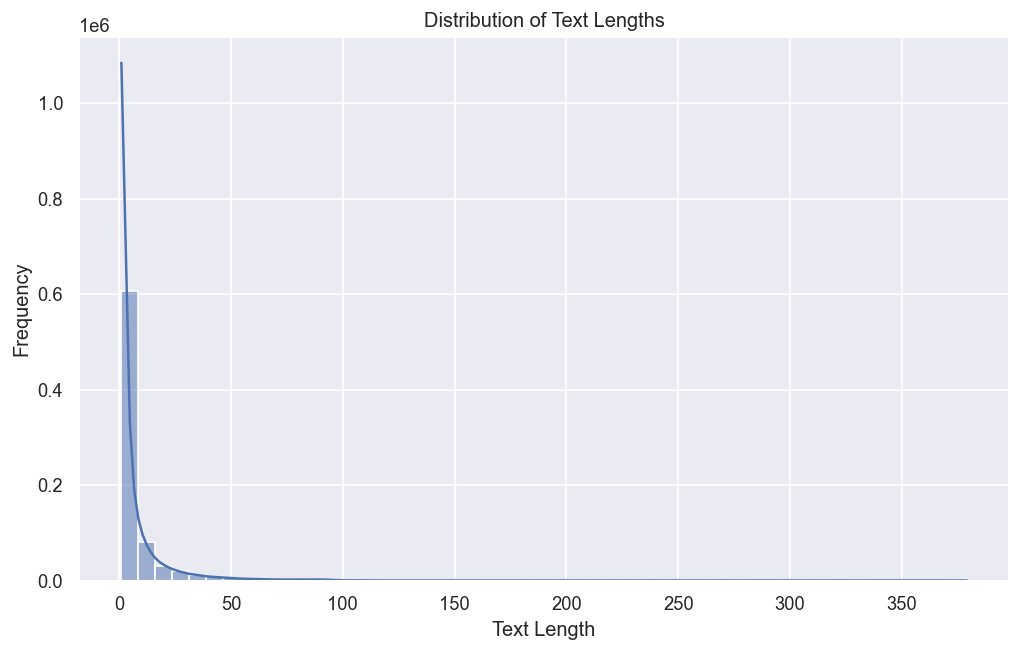

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text_len'], bins=50, kde=True) 
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

##### Summary of graph
Average word count of a text is 7 words. However, there are some texts with high word counts, with the max being 379 words. Long texts can have multiple sentiments to it so it may confuse the model. To counter this, we will do normalisation to analyse the sentiment per sentence/paragraph.

## **EDA Summary**:
- 'sentiment' will be our dependent variable, derived from review_ratings.
- 'review_text' will be used to analze the sentiment.
- There are missing values in review_text which has already been dropped to analyse text lengths.

### Follow up actions:
- Clean text
- Balance classification data using resampling.
- Normalize text length

# Data Preprocessing

In [21]:
df.isna().sum()

Unnamed: 0                  0
review_text                 0
review_rating               0
author_id                 120
author_name                 1
author_app_version     174374
review_datetime_utc         0
review_likes                0
sentiment                   0
text_len                    0
dtype: int64

In [26]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# stemmer = PorterStemmer()
def clean_text(text):
    text = text.lower() # lower case
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>', '', text) # remove HTML tags
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    text = re.sub(r'#\w+', '', text)  # remove #hashtags
    text = re.sub(r'\d+', '', text) # remove numbers e.g. order ID, dates or order numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuations (exclamation marks can indicate emotion, depends on use case)
    text = emoji.demojize(text) # change emoji into text emoji
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # normalize repeated characters, "goooood" to "good"

    # tokenization
    tokens = nltk.word_tokenize(text) # tokenize sentences into word tokens
    tokens = [w for w in tokens if w not in stop_words] # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens] # lemmatization, "running" to "run" to reduce vocab size. Slower than stem to understand deeper text analysis but costs more.
    # tokens = [stemmer.stem(w) for w in tokens] # stemming, either this or lemmatization, not both. Used for speed and scalability (less cost)

    return ' '.join(tokens)
    
def text_preprocessed(df):
    df = addSentiment(df)
    df = change_type(df)
    df = drop_null(df)

    df['clean_text'] = df['review_text'].apply(clean_text)
    
    # only cleaned text and sentiment is needed for this analysis
    return df[['clean_text', 'sentiment']]

df_clean = text_preprocessed(df)
df_clean.head()

,clean_text,sentiment
0,app big step right direction great overview pr...,positive
1,looking buy anything phone product delivered d...,positive
2,great way shopping online please make u choose...,negative
3,thanks lazada app,positive
4,good app,positive


## Summary of Data-Preprocessing

Created functions that can be implemented into pipeline at the end for a seamless workflow.

For reference,
- addSentiment(df)
- text_preprocessed(df)

# Model Training and Evaluation

In [27]:
X = df_clean['clean_text']
y = df_clean['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)

### Logistic Regression (Baseline Model)
TF-IDF reflects how important a word is to a document in a collection or corpus, often used to reflect the relevance of words.
Logistic regression is a classification model which is suitable for multiclass sentiment analysis (positive, negative, neutral) and works well with TF-IDF.

In [31]:
# helper: evaluate any fitted pipeline
def evaluate(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    print("="*60)
    print(f"{name}")
    print("="*60)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 Weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Classification Report: {classification_report(y_test, y_pred)}")
    # confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"])
    fix, ax = plt.subplots(figsize=(6,4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["positive", "neutral", "negative"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return y_pred
    

Logistic Regression
Accuracy: 0.7754
F1 Macro: 0.5898
F1 Weighted: 0.8263
Classification Report:               precision    recall  f1-score   support

    negative       0.75      0.71      0.73     33844
     neutral       0.10      0.47      0.16      9050
    positive       0.96      0.80      0.88    189669

    accuracy                           0.78    232563
   macro avg       0.60      0.66      0.59    232563
weighted avg       0.90      0.78      0.83    232563



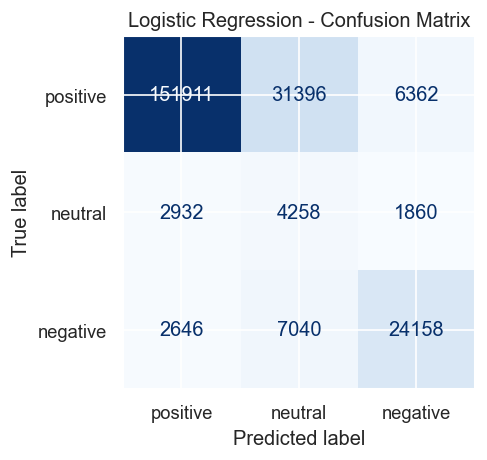

In [32]:
# Create pipeline to prevent data leakage
# class_weight balanced adjusts the importance of each class to help with imbalance
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(C=1, penalty="l2", class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = evaluate("Logistic Regression", lr_pipe, X_test, y_test)

In [33]:
# cross validation (more robust, 5-fold CV on training set to get stable F1 estimates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    lr_pipe, X_train, y_train, cv=cv,
    scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
    n_jobs=-1
)

In [34]:
print(f"CV Accuracy: {cv_scores['test_accuracy'].mean():.4f} + {cv_scores['test_accuracy'].std():.4f}")
print(f"CV F1 Macro: {cv_scores['test_f1_macro'].mean():.4f} + {cv_scores['test_f1_macro'].std():.4f}")

CV Accuracy: 0.7741 + 0.0011
CV F1 Macro: 0.5864 + 0.0010


In [35]:
# Bundle models into a dictionary
models = {
    "logistic": lr_pipe,
}

# Save all models to a single file
joblib.dump(models, "all_models.pkl")

# Load the dictionary of models
# loaded_models = joblib.load("all_models.pkl")

# Access individual models and pred
# preds = loaded_models["logistic"].predict(X_test)

['all_models.pkl']

#### Logistic Regression (Baseline Model) Performance
- Accuracy of **0.78**

### Naives Baye Model

Best Parameters: {'clf__alpha': 0.1, 'clf__fit_prior': True}
Naives Bayes (tuned)
Accuracy: 0.8996
F1 Macro: 0.5800
F1 Weighted: 0.8840
Classification Report:               precision    recall  f1-score   support

    negative       0.74      0.77      0.75     33844
     neutral       0.24      0.02      0.04      9050
    positive       0.93      0.96      0.95    189669

    accuracy                           0.90    232563
   macro avg       0.64      0.59      0.58    232563
weighted avg       0.88      0.90      0.88    232563



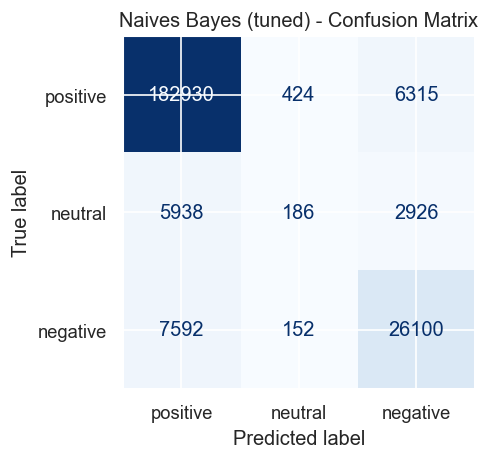

In [36]:
# Naive Bayes model
# if standardscaler was used on dataset, then this model would break silently as it only accepts non-negative features while scaler produces negative features
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

# Hyperparameter grid
param_grid = {
    'clf__alpha': [0.1, 0.5, 1.0, 5.0],      # Laplace smoothing
    'clf__fit_prior': [True, False]          # Use class priors or not
}

# Grid search with 5 fold cross-validation
# Note: f1_macro is used for multiclass (default "f1" is binary only)
gs_nb = GridSearchCV(nb_pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
gs_nb.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", gs_nb.best_params_)

nb_best = gs_nb.best_estimator_
y_pred_nb = evaluate("Naives Bayes (tuned)", nb_best, X_test, y_test)

In [37]:
# Add nb model
# Load existing models
models = joblib.load("all_models.pkl")

# Add new model
models["naives_baye"] = nb_best


# 3. Save back to the same file
joblib.dump(models, "all_models.pkl")


['all_models.pkl']

#### Comparing baseline model against naives baye model
Baseline model had a prediction accuracy of **0.78**, while the naives bayes model had a prediction accuracy of **0.90**. Hence the naives baye model is better so far.


### SVM Model
LinearSVC model will be used instead of SVC model as the SVC model is not optimal for the size of this dataset. I will be using SGDClassifier to track progress and use early stopping with the big dataset in mind.

In [41]:
# # linear SVM model
# linearsvm = LinearSVC(
#     tol=1e-3,       # tolerance for stopping, decrease if needed
#     max_iter=5000,  # increase if there is convergence warnings
#     dual=False      # faster when n_samples > n_features
# )

# # Hyperparameter grid
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'penalty': ['l2'],   # or add 'l1' if you want sparse solutions
#     'loss': ['squared_hinge', 'hinge']
# }

# # GridSearchCV for hyperparameter tuning

# grid_search = GridSearchCV(linearsvm, param_grid, cv=5, scoring='f1', n_jobs=-1)
# grid_search.fit(X_train_scaled, y_bal)

# # Best param
# print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 0.01, 'loss': 'squared_hinge', 'penalty': 'l2'}


-- Epoch 1
Norm: 30.44, NNZs: 4999, Bias: -0.805436, T: 542646, Avg. loss: 0.193382
Total training time: 0.05 seconds.
-- Epoch 2
Norm: 30.35, NNZs: 4999, Bias: -0.796552, T: 1085292, Avg. loss: 0.185573
Total training time: 0.09 seconds.
-- Epoch 3
Norm: 30.30, NNZs: 4999, Bias: -0.797570, T: 1627938, Avg. loss: 0.184991
Total training time: 0.14 seconds.
-- Epoch 4
Norm: 30.33, NNZs: 4999, Bias: -0.794907, T: 2170584, Avg. loss: 0.184560
Total training time: 0.20 seconds.
-- Epoch 5
Norm: 30.30, NNZs: 4999, Bias: -0.793958, T: 2713230, Avg. loss: 0.184561
Total training time: 0.25 seconds.
-- Epoch 6
Norm: 30.28, NNZs: 4999, Bias: -0.793520, T: 3255876, Avg. loss: 0.184417
Total training time: 0.29 seconds.
-- Epoch 7
Norm: 30.29, NNZs: 4999, Bias: -0.796749, T: 3798522, Avg. loss: 0.184356
Total training time: 0.35 seconds.
Convergence after 7 epochs took 0.35 seconds
-- Epoch 1
Norm: 20.50, NNZs: 4999, Bias: -0.997064, T: 542646, Avg. loss: 0.239435
Total training time: 0.04 second

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.3s finished


Linear SVM (SGD, tuned)
Accuracy: 0.8943
F1 Macro: 0.6127
F1 Weighted: 0.8864
Classification Report:               precision    recall  f1-score   support

    negative       0.75      0.76      0.75     33844
     neutral       0.21      0.10      0.14      9050
    positive       0.94      0.96      0.95    189669

    accuracy                           0.89    232563
   macro avg       0.63      0.61      0.61    232563
weighted avg       0.88      0.89      0.89    232563



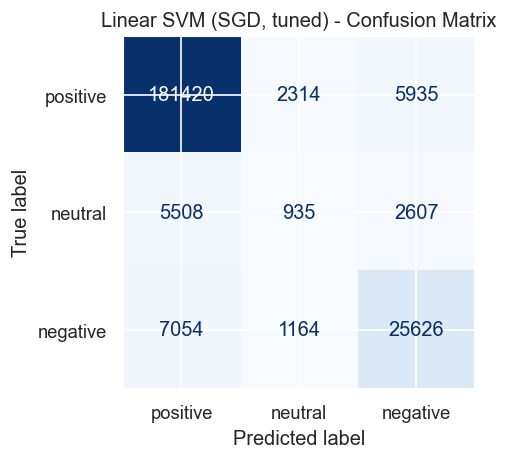

In [40]:
# linear SVM model
from sklearn.linear_model import SGDClassifier

svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', SGDClassifier(
        loss="hinge",        # hinge loss = linear SVM
        max_iter=1000,
        tol=1e-3,
        class_weight="balanced",
        verbose=1,           # <-- print progress each epoch
        random_state=42
    ))
])

# Hyperparameter grid
param_grid_svm = {
    'clf__alpha': [1e-4, 1e-3, 1e-2],   # like 1/C in SVM
    'clf__penalty': ['l2', 'l1']
}

# GridSearchCV for hyperparameter tuning
gs_svm = GridSearchCV(svm_pipe, param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1)
gs_svm.fit(X_train, y_train)

# Best param
print("Best parameters:", gs_svm.best_params_)
svm_best = gs_svm.best_estimator_
y_pred_svm = evaluate("Linear SVM (SGD, tuned)", svm_best, X_test, y_test)

In [41]:
# Add svm model
# Load existing models
models = joblib.load("all_models.pkl")

# Add new model
models["LinearSVC"] = svm_best


# 3. Save back to the same file
joblib.dump(models, "all_models.pkl")

['all_models.pkl']

#### Comparing Naives Bayes model against linear SVC model
Naives Bayes model had a prediction accuracy of **0.90**, while the SVM model had a prediction accuracy of **0.89**. Hence, Naives Bayes model is still better.

## Model Comparison
Accuracy can be misleading, comparison of models will be done to ensure the best model is chosen (F1 Macro treats all class equally, hence better comparison)

In [42]:
# Comparing all models
model_entries = [
    ("Logistic Regression", lr_pipe, y_pred_lr),
    ("Naives Bayes", nb_best, y_pred_nb),
    ("Linear SVM", svm_best, y_pred_svm)
]

results = []

for name, pipeline, y_pred in model_entries:
    per_class = f1_score(y_test, y_pred, average=None, labels=["positive", "neutral", "negative"])
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Macro": round(f1_score(y_test, y_pred, average="macro"), 4),
        "F1 Weighted":  round(f1_score(y_test, y_pred, average="weighted"), 4),
        "F1 Positive":  round(per_class[0], 4),
        "F1 Neutral":   round(per_class[1], 4),
        "F1 Negative":  round(per_class[2], 4),
    })

comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.to_string())

                     Accuracy  F1 Macro  F1 Weighted  F1 Positive  F1 Neutral  F1 Negative
Model                                                                                     
Logistic Regression    0.7754    0.5898       0.8263       0.8752      0.1646       0.7296
Naives Bayes           0.8996    0.5800       0.8840       0.9475      0.0379       0.7545
Linear SVM             0.8943    0.6127       0.8864       0.9458      0.1389       0.7536


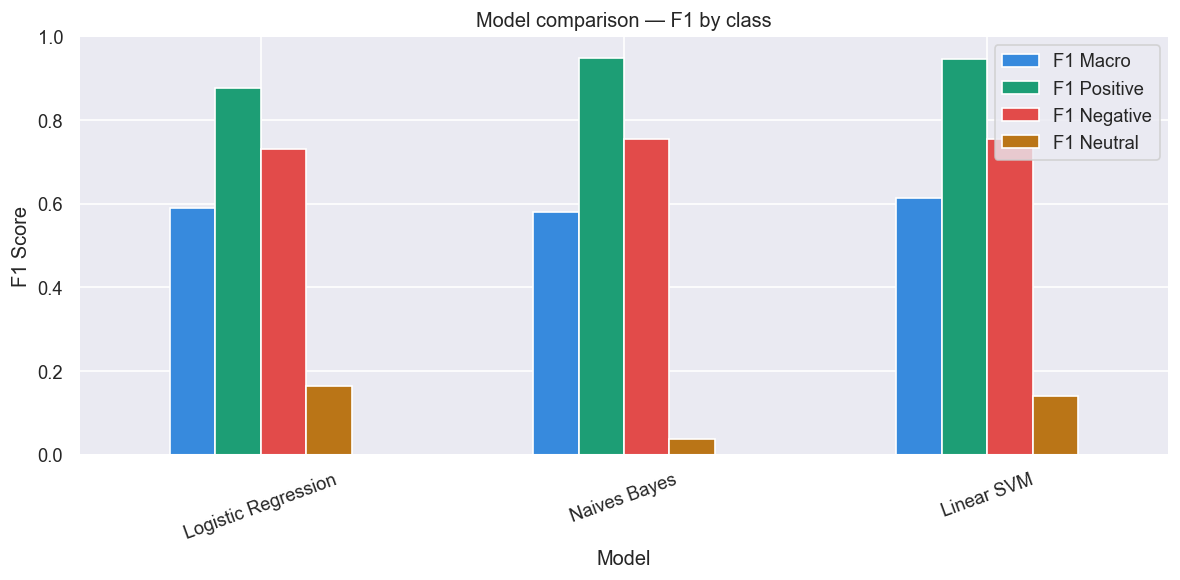

In [45]:
comparison_df[["F1 Macro", "F1 Positive", "F1 Negative", "F1 Neutral"]].plot(
    kind="bar", figsize=(10, 5), rot=20,
    title="Model comparison — F1 by class",
    color=["#378ADD", "#1D9E75", "#E24B4A", "#BA7517"]
)
plt.ylabel("F1 Score"),
plt.ylim(0, 1),
plt.tight_layout(),
plt.show()
    

From the bar chart above, F1 Neutral is the lowest for all models. A rating of 3 does not reliably map to neutral text so decision to collapse to binary (positive and negative) should be considered.

In [49]:
# Save best model and its pipeline
best_name = comparison_df["F1 Macro"].idxmax()
pipeline_map = {name: p for name, p, _ in model_entries}
best_pipeline = pipeline_map[best_name]
print(f"Best model by F1 Macro: {best_name}")
joblib.dump(best_pipeline, "best_pipeline.pkl")
print("Saved: best_pipeline.pkl")

Best model by F1 Macro: Linear SVM
Saved: best_pipeline.pkl


In [52]:
# To use later (no preprocessing needed - pipeline handles everything):

# pipeline = joblib.load("best_pipeline.pkl")
# pipeline.predict(["This app crashes every time I open it"])  #["negative"]
# pipeline.predict(["Great deals and fast shipping!"])         #["positive"]

array(['negative'], dtype='<U8')

# Analysis of Results
## Word Clouds
- What are people saying?

In [79]:
# !pip uninstall -y pillow wordcloud
# !pip install pillow wordcloud

In [84]:
import matplotlib.font_manager as fm

# font_path = fm.findfont("DejaVu Sans", fallback_to_default=True)
font_path = "c:\\users\\alsto\\anaconda3\\lib\\site-packages\\wordcloud\\DroidSansMono.ttf"

In [89]:
pip install pillow==10.4.0 wordcloud matplotlib

  Using cached wordcloud-1.9.6-cp39-cp39-win_amd64.whl (306 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\alsto\\anaconda3\\Lib\\site-packages\\wordcloud\\DroidSansMono.ttf'
Consider using the `--user` option or check the permissions.



In [91]:
WordCloud().generate("hello world")

ValueError: Only supported for TrueType fonts

ValueError: Only supported for TrueType fonts

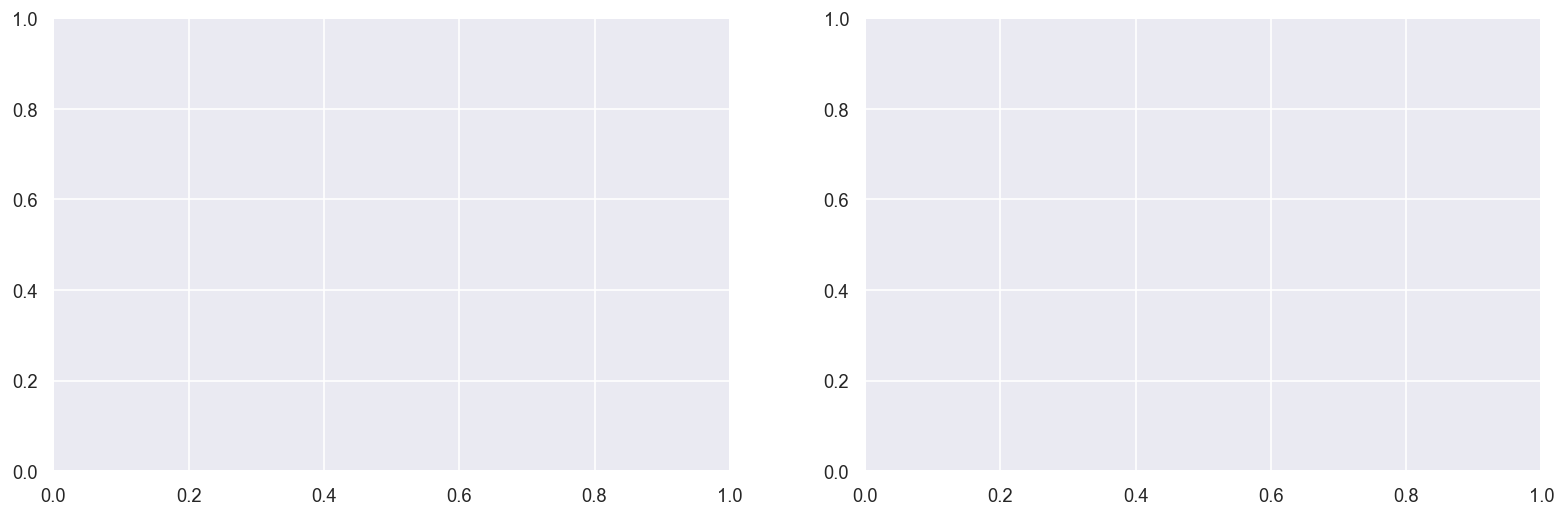

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sentiment, cmap in [
    (axes[0], "positive", "Greens"),
    (axes[1], "negative", "Reds")
]:
    
    subset = df[df["sentiment"] == sentiment]["clean_text"]
    
    text = " ".join(
        subset.sample(min(5000, len(subset)), random_state=42)
    )
    
    wc = WordCloud(
        width=800, 
        height=400,
        background_color="white",
        colormap=cmap,
        max_words=80,
        font_path=font_path,
    ).generate(text)
    
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Most common words — {sentiment} reviews", fontsize=13)

plt.tight_layout()
plt.show()